In [1]:
# Installing dependencies if Colab
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

if IN_COLAB:
    print("In Colab, installing dependencies", flush=True)
    !pip install biopython jaxtyping circuitsvis transformer-lens==3.0.0 torchao==0.17.0 transformers==4.57.5 datasets==4.4.2

    print("Mounting Colab")
    from google.colab import drive
    drive.mount('/content/drive')
    %cd drive/MyDrive/mutational-embedding-vectors/notebooks

In Colab, installing dependencies
Mounting Colab
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/mutational-embedding-vectors/notebooks


In [2]:
import argparse
import os
import pickle
import sys
import typing

import pandas as pd
import torch
from Bio import SeqIO
from typing import List, Union, Optional, Callable, Sequence
from transformers import (
    EsmForMaskedLM,
    EsmConfig,
    PretrainedConfig,
    EsmTokenizer,
    DataCollatorForLanguageModeling,
    Trainer
)

from tokenizers import Tokenizer
import torch
import torch.nn.functional as F
from torch import Tensor, nn

import einops
import yaml
import sys
import json
import functools
import os
import shutil

import numpy as np
from huggingface_hub import hf_hub_download
from peft import LoraConfig, get_peft_model
from datasets import Dataset, load_dataset
import math
from tqdm import tqdm

from matplotlib import pyplot as plt

from jaxtyping import Bool, Float, Int
from plotly.subplots import make_subplots
import plotly.express as px
from plotly_utils import (
    imshow,
    line,
    bar
)

import circuitsvis as cv
from IPython.display import display, HTML
from IPython import get_ipython
ip = get_ipython()
if not ip.extension_manager.loaded:
    ip.extension_manager.load('autoreload')
    %autoreload 2

In [3]:
import transformer_lens
import transformer_lens.utils as utils
from transformer_lens.hook_points import (
    HookedRootModule,
    HookPoint,
)

# Hooking utilities
from transformer_lens import (
    HookedTransformer,
    HookedTransformerConfig,
    FactoredMatrix,
    ActivationCache,
)

sys.path.append("../scripts")
from compute_node_embeddings import load_sequences, get_protein_sequence
from branches import json_to_tree
from interp_utils import get_hooked_state_dict, get_hooked_esm_config, get_logits_hooked_esm

In [4]:
from covfit_stuff.config import Config, ModelConfig
from covfit_stuff.esm_regression import load_model_for_inference, get_model_predictions, EsmForRegression
import tempfile
sys.path.append("../config")
import experiment_config
import interp_utils

In [5]:
!pip list | grep plotly

plotly                                5.24.1


# This notebook contains all the code needed to reproduce the experiments to find the L455F circuit in CovFit

For the path-patching experiments, due to GPU constraints, we were only able to use ~80 counterfactual pairs of sequences.

We take a random sample of 80 sequences with the L455 amino acid and create corresponding synthetic F455 sequences (setting the seed=0 for exact reproducibility)

## Load Model

In [6]:
torch.autograd.grad_mode.set_grad_enabled(False)
torch.set_float32_matmul_precision("medium")
# small thing to turn off annoying wand questions
os.environ["WANDB_DISABLED"] = "true"
CONTEXT_LEN = experiment_config.CONTEXT_LEN
device = experiment_config.device
print(f"device = {device}")

device = cuda


In [7]:
model_name = "facebook/esm2_t33_650M_UR50D"
device = "cuda"
CONTEXT_LEN = 1024
torch.autograd.grad_mode.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [8]:
esm_config, esm_covfit, (hooked_esm_covfit, get_logit_covfit) = interp_utils.setup_and_load_model(experiment_config, "covfit")
torch.cuda.empty_cache()

(covfit) esm_model <All keys matched successfully>
hooked_model:  <All keys matched successfully>
Note: covfit get_logit_hooked takes 2 inputs -- output and tok_id


In [9]:
tokenizer_config = {}
tokenizer_config["vocab_file"] = experiment_config.VOCAB_FILE
tokenizer_config["model_max_length"] = experiment_config.CONTEXT_LEN

with open(experiment_config.SPECIAL_TOK_MAP, "r") as f:
    tokenizer_config = {**tokenizer_config, **(json.load(f))}

with open(tokenizer_config["vocab_file"], "r") as f:
    f_data = f.read().split("\n")
    aa_to_toks_map = {i:f_data[i] for i in range(len(f_data))}
    aa_to_toks_map_rev = {aa_to_toks_map[k]:k for k in aa_to_toks_map.keys()}

tokenizer = EsmTokenizer(**tokenizer_config)
original_task_id_infos = torch.load(experiment_config.TASK_IDS_FILE, map_location=device)

In [10]:
component_name_map = dict()
for l in range(esm_config.num_hidden_layers + 1):
    if l < esm_config.num_hidden_layers:
        component_name_map[l] = f"blocks.{l}.hook_resid_pre"

    # final layer
    elif l == esm_config.num_hidden_layers:
        component_name_map[l] = f"unembed.hook_in"

logit_id = original_task_id_infos["fitness_USA"]
# clean up memory
torch.cuda.empty_cache()

In [11]:
def get_rev_names(id_seq):
    """
    Given seq x in all_uniq_seqs, get the corresponding name(s) of sequences that have the same spike protein
    """
    if type(id_seq) == int:
        id_seq = [id_seq]

    rev_name_dict = {}
    for id_s in id_seq:
        name_idx = np.argwhere(np.array(seq_idxs) == id_seq)[:,0]
        rev_name_dict[id_s] = [seq_names[x] for x in name_idx]
    return rev_name_dict

## Load Data

In [12]:
L455F_mut_dict = ("L455F", lambda x: True)

In [13]:
# data loading
with open("../config/pathogen_config.yaml", "r") as config_file:
    config = yaml.safe_load(config_file)
pathogens = list(config["pathogens"].keys())
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer,return_tensors='pt',mlm_probability=0.15)

In [14]:
MAX_LEN=1024
pathogen_suffixes = ["africa", "asia", "europe", "north_america", "oceania", "south_america"]
pathogen_name = "sars_cov_2_spike"
protein_coords = config["pathogens"][f"{pathogen_name}_africa"]["protein_coords"]

In [15]:
name_to_clade_dict = dict()
for suff in pathogen_suffixes:
    print(suff)
    with open(f"../data/pathogen/{pathogen_name}_{suff}/auspice.json", "r") as f:
        tree_json = json.load(f)
        test_tree = json_to_tree(tree_json)
        nodes = list(test_tree.find_clades(order="postorder"))
        name_to_clade_dict.update({n.name:n.node_attrs["clade_membership"]["value"] for n in nodes})

africa
asia
europe
north_america
oceania
south_america


In [16]:
"""
all_uniq_seqs - seqs used in training
seq_names - names of ALL sequences
all_seqs - ALL sequences
seq_idxs - map from seq_names to uniq_seqs, i.e. seq_names[i] is for uniq_seqs[seq_idxs[i]]
"""

all_seqs = []
seq_names = []
seq_idxs = []
all_uniq_seqs = []

for suff in pathogen_suffixes:
    fasta_file = f"../data/pathogen/{pathogen_name}_{suff}/alignment.fasta"
    data = load_sequences(fasta_file)
    sequence_names, sequences = list(zip(*list(data.items())))
    sequences = [get_protein_sequence(x, protein_coords) for x in sequences]

    keep_idx = [i for i,x in enumerate(sequences) if len(x.replace("-","")) > (CONTEXT_LEN // 5) * 4]
    sequences = [sequences[i] for i in keep_idx]
    sequence_names = [sequence_names[i] for i in keep_idx]

    uniq_seqs_suff, unique_inv_idx  = np.unique(sequences, return_inverse=True) # For the purpose of eval, I only care about unique sequences

    all_seqs.extend(sequences)
    seq_names.extend(sequence_names)
    seq_idxs.extend(unique_inv_idx + len(all_uniq_seqs))
    all_uniq_seqs.extend(uniq_seqs_suff)

all_uniq_seqs, unique_inv_idx  = np.unique(all_uniq_seqs, return_inverse=True) # For the purpose of eval, I only care about unique sequences
seq_idxs = [unique_inv_idx[idx] for idx in seq_idxs]
all_uniq_seqs = list(all_uniq_seqs)

# identical code to how it's compute_node_embeddings.py
tok_output = tokenizer(all_uniq_seqs, return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN)
tok_seqs = tok_output.input_ids.to(device)
tok_masks = tok_output.attention_mask.to(device)

print(pathogen_name)
print(f"Number unique sequences: {len(all_uniq_seqs)}")
print(tok_seqs.shape)

sars_cov_2_spike
Number unique sequences: 4615
torch.Size([4615, 1024])


Mutation = L 455 F; L, F; 80 total seqs
455 80 



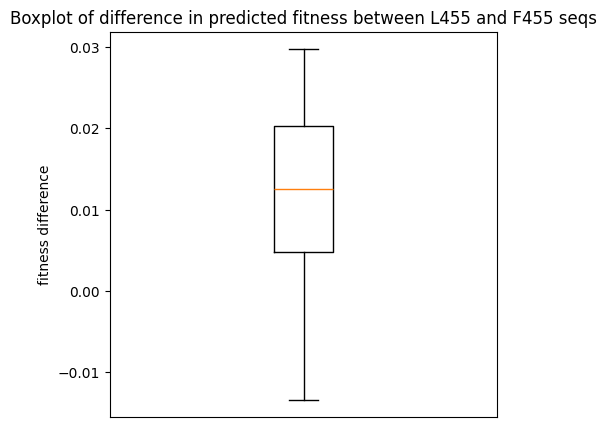

In [17]:
np.random.seed(0)
mut = L455F_mut_dict[0]
seq_selector = L455F_mut_dict[1]

wt_resid = mut[0]
mut_resid = mut[-1]
site = int(mut[1:-1])

uniq_seqs = np.unique([all_uniq_seqs[seq_idxs[i]] for i,n in enumerate(seq_names) if seq_selector(name_to_clade_dict[n])])
rand_seqs = np.random.permutation(uniq_seqs)

seq_orig_idx = [x for x in rand_seqs if x[site-1] == wt_resid][:80]
seq_new_idx = [x[:site-1] + mut_resid + x[site:] for x in seq_orig_idx]

print(f"Mutation = {wt_resid} {site} {mut_resid}; {seq_orig_idx[10][site-1]}, {seq_new_idx[10][site-1]}; {len(seq_orig_idx)} total seqs")

L455_toks = tokenizer(seq_orig_idx, return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN).input_ids.to(device)
F455_toks = tokenizer(seq_new_idx, return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN).input_ids.to(device)

sanity_check = (L455_toks !=  F455_toks).sum(dim=0)
print(torch.arange(L455_toks.shape[-1])[sanity_check.to(bool).cpu()].item(), sanity_check[site].item(), "\n")

# Plot differences as boxplot
orig_output = get_logit_covfit(hooked_esm_covfit(L455_toks), logit_id)
torch.cuda.empty_cache()
new_output = get_logit_covfit(hooked_esm_covfit(F455_toks), logit_id)
torch.cuda.empty_cache()

fig,ax = plt.subplots(1,1,figsize=(5,5))
ax.set_title("Boxplot of difference in predicted fitness between L455 and F455 seqs")
ax.boxplot((new_output - orig_output).cpu())
ax.set_ylabel("fitness difference")
ax.set_xticks([])
plt.show()

del orig_output
del new_output
torch.cuda.empty_cache()

## Path patching Experiments

All experiments use the same path-patching metric, which equals 0 when the performance is conserved (i.e. the predicted fitness is no different that the synthetically mutated sequence) and -1 when the performance is destroyed (i.e. the predicted fitness is equal to that of the wt sequences)

We use two distinct methods of path-patching:

*   <b>Absolute Path Patching</b> - Measures the DIRECT causal impact of components on one another
*   <b>Path Patching</b> - Measures the causal impact of components on one another mediated through MLPs



In [18]:
def path_patching_metric(
    logits: Float[Tensor, "batch"],
    corrupted_logit_mean: float,
    clean_logit_mean: float,
):
    """
    Equals 0 when performance is conserved (i.e. high fitness sequences still high fitness)
    Equals -1 when performance is destroyed (high fitness sequence is degraded)
    """

    return ((logits - clean_logit_mean) / (clean_logit_mean - corrupted_logit_mean)).mean().item()

In [19]:
# clean = high fitness
# corr = low fitness

clean_toks = F455_toks
corr_toks = L455_toks

corrupted_logit_mean = get_logit_covfit(hooked_esm_covfit(corr_toks), logit_id).mean().item()
clean_logit_mean = get_logit_covfit(hooked_esm_covfit(clean_toks), logit_id).mean().item()
print(corrupted_logit_mean - clean_logit_mean)
torch.cuda.empty_cache()

-0.012552917003631592


### Absolute Path Patching experiements
<u>Patching to attn. heads and measuring final fitness</u>

In [20]:
hooked_esm_covfit.reset_hooks(including_permanent=False)
torch.cuda.empty_cache()

In [21]:
# only need attention info
_, new_cache = hooked_esm_covfit.run_with_cache(corr_toks, names_filter=lambda x: "hook_z" in x)
torch.cuda.empty_cache()

In [22]:
abs_patch_head = interp_utils.path_patch_head_absolute_direct(
    hooked_esm_covfit,
    orig_dataset=clean_toks,
    patching_metric=functools.partial(path_patching_metric, corrupted_logit_mean=corrupted_logit_mean, clean_logit_mean=clean_logit_mean),
    get_logit_hooked=get_logit_covfit,
    new_cache=new_cache,
    logit_id=logit_id
)
del _
del new_cache
torch.cuda.empty_cache()

100%|██████████| 660/660 [00:04<00:00, 157.40it/s]


In [23]:
fig = imshow(
    abs_patch_head.T,
    labels={"x": "Layer", "y": "Head", "color": "Change in fitness"},
    title="Absolute path patching change in fitness -- L455 into F455 (0 = conserved, -1 = destroyed)",
    width=1200,
    height=800,
    range_color=(-0.5,0.5),
    return_fig=True
)
fig.write_html("../figures/L455F_path_patching/abs_patch_attn_to_fitness.html")
fig.show()

<u>Patching to MLP and measuring final fitness</u>

In [24]:
hooked_esm_covfit.reset_hooks(including_permanent=False)
torch.cuda.empty_cache()

In [25]:
all_mlp_names = [f"blocks.{layer}.hook_mlp_out" for layer in range(hooked_esm_covfit.cfg.n_layers)]
# only need mlp info
_, new_cache = hooked_esm_covfit.run_with_cache(corr_toks, names_filter=all_mlp_names)
torch.cuda.empty_cache()

In [26]:
absolute_path_patch_mlp_results = interp_utils.path_patch_mlp_absolute_direct(
    hooked_esm_covfit,
    orig_dataset=clean_toks,
    patching_metric=functools.partial(path_patching_metric, corrupted_logit_mean=corrupted_logit_mean, clean_logit_mean=clean_logit_mean),
    get_logit_hooked=get_logit_covfit,
    new_cache=new_cache,
    logit_id=logit_id
)
del _
del new_cache
torch.cuda.empty_cache()

100%|██████████| 33/33 [00:00<00:00, 320.31it/s]


In [27]:
fig = imshow(
    absolute_path_patch_mlp_results[None,:],
    labels={"x": "MLP", "y": "", "color": "Change in fitness"},
    title="Absolute path patching change in fitness -- L455 into F455 (0 = conserved, -1 = destroyed)",
    width=1000,
    height=400,
    range_color=(-0.7,0.7),
    return_fig=True
)
fig.write_html("../figures/L455F_path_patching/abs_patch_MLP_to_fitness.html")
fig.show()

<u>Patching to attn. heads and measuring impact on 32.5, 32.8, 32.13</u>

In [28]:
hooked_esm_covfit.reset_hooks(including_permanent=False)
torch.cuda.empty_cache()

In [29]:
# only need attention info
_, new_cache = hooked_esm_covfit.run_with_cache(corr_toks, names_filter=lambda x: "hook_z" in x)
del _
torch.cuda.empty_cache()
_, orig_cache = hooked_esm_covfit.run_with_cache(clean_toks, names_filter=lambda x: "hook_z" in x)
torch.cuda.empty_cache()

In [30]:
all_abs_patch_32_8_5_13_results = []
for receiver_input in ["q", "k", "v"]:
    abs_patch_32_8_5_13 = interp_utils.abs_path_patch_receiver_heads(
        model=hooked_esm_covfit,
        receiver_heads = [(32,5), (32,8), (32,13)], # (layer,head)
        receiver_input = receiver_input, #one of {"q", "k", "v"}
        orig_dataset = clean_toks,
        patching_metric = functools.partial(path_patching_metric, corrupted_logit_mean=corrupted_logit_mean, clean_logit_mean=clean_logit_mean),
        get_logit_hooked=get_logit_covfit,
        new_cache = new_cache, # cached attn. z
        orig_cache = orig_cache, # cached attn. z
        logit_id=logit_id
    )
    torch.cuda.empty_cache()
    all_abs_patch_32_8_5_13_results.append(abs_patch_32_8_5_13)

del _
del new_cache
del orig_cache
torch.cuda.empty_cache()

100%|██████████| 640/640 [20:55<00:00,  1.96s/it]


In [31]:
all_abs_patch_32_8_5_13_results_tensor = torch.stack(all_abs_patch_32_8_5_13_results, dim=0)

In [32]:
fig = imshow(
    all_abs_patch_32_8_5_13_results_tensor,
    labels={"x": "Head", "y": "Layer", "color": "Change in fitness"},
    title="Direct effect on Head 32.5, 32.8, 32.13 -- L455 run into F455 (0 = conserved, -1 = destroyed)",
    facet_labels=["Query-composition", "Key-composition", "Value-composition"],
    width=1200,
    height=800,
    facet_col=0,
    range_color=(-0.5,0.5),
    return_fig=True
)
fig.write_html("../figures/L455F_path_patching/abs_patch_attn_to_attn32_5_8_13.html")
fig.show()

<u>Patching to MLP and measuring impact 32.5, 32.8, 32.13</u>

In [35]:
hooked_esm_covfit.reset_hooks(including_permanent=False)
torch.cuda.empty_cache()

In [37]:
mlp_names = [f"blocks.{layer}.hook_mlp_out" for layer in range(hooked_esm_covfit.cfg.n_layers)]

In [38]:
# cache MLP outputs
_, orig_cache = hooked_esm_covfit.run_with_cache(clean_toks, names_filter=mlp_names)
torch.cuda.empty_cache()
_, new_cache = hooked_esm_covfit.run_with_cache(corr_toks, names_filter=mlp_names)
torch.cuda.empty_cache()

In [39]:
all_abs_mlp_patch_32_5_8_13_results = []
for receiver_input in ["q", "k", "v"]:
    abs_mlp_patch_32_5_8_13 = interp_utils.abs_path_patch_mlp_to_receiver_heads(
        model=hooked_esm_covfit,
        receiver_heads = [(32,5), (32,8), (32,13)], # (layer,head)
        receiver_input = receiver_input, #one of {"q", "k", "v"}
        orig_dataset = clean_toks,
        patching_metric = functools.partial(path_patching_metric, corrupted_logit_mean=corrupted_logit_mean, clean_logit_mean=clean_logit_mean),
        get_logit_hooked=get_logit_covfit,
        new_cache = new_cache, # cached attn. mlp
        orig_cache = orig_cache, # cached attn. mlp
        logit_id=logit_id
    )
    torch.cuda.empty_cache()
    all_abs_mlp_patch_32_5_8_13_results.append(abs_mlp_patch_32_5_8_13)

del _
del new_cache
del orig_cache
torch.cuda.empty_cache()

100%|██████████| 32/32 [01:02<00:00,  1.96s/it]


In [41]:
all_abs_mlp_patch_32_5_8_13_results_tensor = torch.stack(all_abs_mlp_patch_32_5_8_13_results, dim=0)
hooked_esm_covfit.reset_hooks(including_permanent=False)

In [43]:
fig = imshow(
    all_abs_mlp_patch_32_5_8_13_results_tensor,
    labels={"x": "MLP", "y": "q-,k-,v- composition", "color": "Change in fitness"},
    title="Direct effect on Head 32.5, 32.8, 32.13 -- L455 into F455 (0 = conserved, -1 = destroyed)",
    width=1300,
    height=800,
    y = ["Query-composition","Key-composition","Value-composition"],
    range_color=(-0.6,0.6),
    return_fig=True
)

fig.write_html("../figures/L455F_path_patching/abs_patch_MLP_to_attn32_5_8_13.html")
fig.show()

In [44]:
hooked_esm_covfit.reset_hooks(including_permanent=False)
torch.cuda.empty_cache()

<u>Patching to attn. heads and measuring impact on MLP 31, 30</u>

In [45]:
hooked_esm_covfit.reset_hooks(including_permanent=False)
torch.cuda.empty_cache()

In [46]:
# cache attention outputs
_, orig_cache = hooked_esm_covfit.run_with_cache(clean_toks, names_filter=lambda name: name.endswith("z"))
torch.cuda.empty_cache()
_, new_cache = hooked_esm_covfit.run_with_cache(corr_toks, names_filter=lambda name: name.endswith("z"))
torch.cuda.empty_cache()

In [48]:
head_path_patch_all_mlp = []
for mlp_idx in [31, 30]:
    head_path_patch_mlp_i = interp_utils.abs_path_patch_to_mlp(
        hooked_esm_covfit,
        receiver_mlps = [mlp_idx],
        orig_dataset = clean_toks,
        patching_metric = functools.partial(path_patching_metric, corrupted_logit_mean=corrupted_logit_mean, clean_logit_mean=clean_logit_mean),
        get_logit_hooked=get_logit_covfit,
        new_cache=new_cache,
        orig_cache=orig_cache,
        logit_id=logit_id
    )
    head_path_patch_all_mlp.append(head_path_patch_mlp_i)

del _
del new_cache
del orig_cache
torch.cuda.empty_cache()

100%|██████████| 620/620 [20:20<00:00,  1.97s/it]


In [49]:
head_path_patch_all_mlp_tensor = torch.stack(head_path_patch_all_mlp, dim=0)

In [50]:
fig = imshow(
    head_path_patch_all_mlp_tensor,
    labels={"x": "Head", "y": "Layer", "color": "Change in fitness"},
    title="Absolute path patching direct effect on different MLPs, L455 into F455 (0 = conserved, -1 = destroyed)",
    facet_labels=[f"MLP{mlp_idx}" for mlp_idx in [31, 30]],
    width=1600,
    height=800,
    facet_col=0,
    range_color=(-0.5,0.5),
    return_fig=True
)

fig.write_html("../figures/L455F_path_patching/abs_patch_attn_to_MLP30_31.html")
fig.show()

<u>Patching to MLP and measuring impact on MLP 31, 30</u>

In [51]:
hooked_esm_covfit.reset_hooks(including_permanent=False)
torch.cuda.empty_cache()

In [53]:
resid_post_names = [f"blocks.{layer}.hook_resid_mid" for layer in range(hooked_esm_covfit.cfg.n_layers)]

In [55]:
# cache MLP outputs
_, orig_cache = hooked_esm_covfit.run_with_cache(clean_toks, names_filter=resid_post_names)
torch.cuda.empty_cache()
_, new_cache = hooked_esm_covfit.run_with_cache(corr_toks, names_filter=resid_post_names)
torch.cuda.empty_cache()

In [57]:
mlp_abs_path_patch_31_30 = []
for mlp in [[31],[30],[31,30]]:
    mlp_abs_path_patch_mlp_i = interp_utils.abs_direc_path_patch_mlp_to_mlp(
        hooked_esm_covfit,
        receiver_mlps=mlp,
        orig_dataset=clean_toks,
        patching_metric=functools.partial(path_patching_metric, corrupted_logit_mean=corrupted_logit_mean, clean_logit_mean=clean_logit_mean),
        get_logit_hooked=get_logit_covfit,
        new_cache=new_cache,
        orig_cache=orig_cache,
        logit_id=logit_id
    )
    torch.cuda.empty_cache()
    mlp_abs_path_patch_31_30.append(mlp_abs_path_patch_mlp_i)

del _
del new_cache
del orig_cache
torch.cuda.empty_cache()

100%|██████████| 31/31 [01:01<00:00,  1.98s/it]


In [58]:
mlp_abs_path_patch_31_30_tensor = torch.stack(mlp_abs_path_patch_31_30, dim=0)

In [60]:
fig = imshow(
    mlp_abs_path_patch_31_30_tensor,
    labels={"x": "MLP patched FROM", "y": "MLP patch TO", "color": "Change in fitness"},
    title="Absolute path patching to MLP 30,31, examining change in fitness L455 to F455 (0 = conserved, -1 = destroyed)",
    width=1400,
    height=800,
    range_color=(-0.5,0.5),
    y = ["31","30","[31,30]"],
    return_fig=True
)

fig.write_html("../figures/L455F_path_patching/abs_patch_MLP_to_MLP30_31.html")
fig.show()

<u>Patching to attn. heads and measuring impact on 31.7</u>

In [61]:
hooked_esm_covfit.reset_hooks(including_permanent=False)
torch.cuda.empty_cache()

In [62]:
# only need attention info
_, new_cache = hooked_esm_covfit.run_with_cache(corr_toks, names_filter=lambda x: "hook_z" in x)
torch.cuda.empty_cache()
_, orig_cache = hooked_esm_covfit.run_with_cache(clean_toks, names_filter=lambda x: "hook_z" in x)
torch.cuda.empty_cache()

In [63]:
all_abs_patch_31_7_results = []
for receiver_input in ["q", "k", "v"]:
    abs_patch_31_7 = interp_utils.abs_path_patch_receiver_heads(
        model=hooked_esm_covfit,
        receiver_heads = [(31,7)], # (layer,head)
        receiver_input = receiver_input, #one of {"q", "k", "v"}
        orig_dataset = clean_toks,
        patching_metric = functools.partial(path_patching_metric, corrupted_logit_mean=corrupted_logit_mean, clean_logit_mean=clean_logit_mean),
        get_logit_hooked=get_logit_covfit,
        new_cache = new_cache, # cached attn. z
        orig_cache = orig_cache, # cached attn. z
        logit_id=logit_id
    )
    torch.cuda.empty_cache()
    all_abs_patch_31_7_results.append(abs_patch_31_7)

del _
del new_cache
del orig_cache
torch.cuda.empty_cache()

100%|██████████| 620/620 [20:16<00:00,  1.96s/it]


In [64]:
all_abs_patch_31_7_results_tensor = torch.stack(all_abs_patch_31_7_results, dim=0)

In [66]:
fig = imshow(
    all_abs_patch_31_7_results_tensor,
    labels={"x": "Head", "y": "Layer", "color": "Change in fitness"},
    title="Direct effect on Head 31.7 -- L455 into F455 (0 = conserved, -1 = destroyed)",
    facet_labels=["Query-composition", "Key-composition", "Value-composition"],
    width=1200,
    height=800,
    facet_col=0,
    range_color=(-0.5,0.5),
    return_fig=True
)

fig.write_html("../figures/L455F_path_patching/abs_patch_attn_to_attn31_7.html")
fig.show()

<u>Patching to MLP and measuring impact on 31.7</u>

In [67]:
hooked_esm_covfit.reset_hooks(including_permanent=False)
torch.cuda.empty_cache()

In [70]:
mlp_names = [f"blocks.{layer}.hook_mlp_out" for layer in range(hooked_esm_covfit.cfg.n_layers)]

In [71]:
# cache MLP outputs
_, orig_cache = hooked_esm_covfit.run_with_cache(clean_toks, names_filter=mlp_names)
torch.cuda.empty_cache()
_, new_cache = hooked_esm_covfit.run_with_cache(corr_toks, names_filter=mlp_names)
torch.cuda.empty_cache()

In [72]:
all_abs_mlp_patch_31_7_results = []
for receiver_input in ["q", "k", "v"]:
    abs_mlp_patch_31_7 = interp_utils.abs_path_patch_mlp_to_receiver_heads(
        model=hooked_esm_covfit,
        receiver_heads = [(31,7)], # (layer,head)
        receiver_input = receiver_input, #one of {"q", "k", "v"}
        orig_dataset = clean_toks,
        patching_metric = functools.partial(path_patching_metric, corrupted_logit_mean=corrupted_logit_mean, clean_logit_mean=clean_logit_mean),
        get_logit_hooked=get_logit_covfit,
        new_cache = new_cache, # cached attn. mlp
        orig_cache = orig_cache, # cached attn. mlp
        logit_id=logit_id
    )
    torch.cuda.empty_cache()
    all_abs_mlp_patch_31_7_results.append(abs_mlp_patch_31_7)

del _
del new_cache
del orig_cache
torch.cuda.empty_cache()

100%|██████████| 31/31 [01:00<00:00,  1.95s/it]


In [73]:
all_abs_mlp_patch_31_7_results_tensor = torch.stack(all_abs_mlp_patch_31_7_results, dim=0)

In [74]:
fig = imshow(
    all_abs_mlp_patch_31_7_results_tensor,
    labels={"x": "MLP", "y": "q-,k-,v- composition", "color": "Change in fitness"},
    title="Absolute path patching direct effect on Head 31.7, L455 into F455 (0 = conserved, -1 = destroyed)",
    width=1300,
    height=800,
    y = ["Query-composition","Key-composition","Value-composition"],
    range_color=(-0.6,0.6),
    return_fig=True
)

fig.write_html("../figures/L455F_path_patching/abs_patch_MLP_to_attn31_7.html")
fig.show()

<u>Patching to MLP and measuring impact on all MLP</u>

In [75]:
hooked_esm_covfit.reset_hooks(including_permanent=False)
torch.cuda.empty_cache()

In [76]:
resid_post_names = [f"blocks.{layer}.hook_resid_mid" for layer in range(hooked_esm_covfit.cfg.n_layers)]

In [79]:
# cache MLP outputs
_, orig_cache = hooked_esm_covfit.run_with_cache(clean_toks, names_filter=resid_post_names)
torch.cuda.empty_cache()
_, new_cache = hooked_esm_covfit.run_with_cache(corr_toks, names_filter=resid_post_names)
torch.cuda.empty_cache()

In [80]:
mlp_abs_path_patch_ALL = []
for mlp in [[i] for i in range(hooked_esm_covfit.cfg.n_layers)]:
    mlp_abs_path_patch_mlp_i = interp_utils.abs_direc_path_patch_mlp_to_mlp(
        hooked_esm_covfit,
        receiver_mlps=mlp,
        orig_dataset=clean_toks,
        patching_metric=functools.partial(path_patching_metric, corrupted_logit_mean=corrupted_logit_mean, clean_logit_mean=clean_logit_mean),
        get_logit_hooked=get_logit_covfit,
        new_cache=new_cache,
        orig_cache=orig_cache,
        logit_id=logit_id
    )
    torch.cuda.empty_cache()
    mlp_abs_path_patch_ALL.append(mlp_abs_path_patch_mlp_i)

del _
del new_cache
del orig_cache
torch.cuda.empty_cache()

0it [00:00, ?it/s]
100%|██████████| 32/32 [01:02<00:00,  1.97s/it]


In [81]:
mlp_abs_path_patch_ALL_tensor = torch.stack(mlp_abs_path_patch_ALL, dim=0)

In [82]:
fig = imshow(
    mlp_abs_path_patch_ALL_tensor,
    labels={"x": "MLP patched FROM", "y": "MLP patch TO", "color": "Change in fitness"},
    title="Absolute path patching across all MLP, examining change in fitness LOW into HIGH (0 = conserved, -1 = destroyed)",
    width=1400,
    height=800,
    range_color=(-0.5,0.5),
    return_fig=True
)

fig.write_html("../figures/L455F_path_patching/abs_patch_MLP_to_MLP_ALL.html")
fig.show()

### Path Patching Experiments
<u>Path patching to attn. heads and measuring impact on MLP 32.5, 32.8, 32.13</u>

In [20]:
hooked_esm_covfit.reset_hooks(including_permanent=False)
torch.cuda.empty_cache()

In [21]:
# cache attention outputs
_, orig_cache = hooked_esm_covfit.run_with_cache(clean_toks, names_filter=lambda name: name.endswith("z"))
torch.cuda.empty_cache()
_, new_cache = hooked_esm_covfit.run_with_cache(corr_toks, names_filter=lambda name: name.endswith("z"))
torch.cuda.empty_cache()

In [22]:
path_patch_32_5_8_13_qkv = []
for receiver_input in ["q","k","v"]:
    path_patch_32 = interp_utils.get_path_patch_head_to_heads(
        hooked_esm_covfit,
        receiver_heads=[(32,5),(32,8),(32,13)],
        receiver_input=receiver_input,
        new_dataset=corr_toks,
        orig_dataset=clean_toks,
        patching_metric=functools.partial(path_patching_metric, corrupted_logit_mean=corrupted_logit_mean, clean_logit_mean=clean_logit_mean),
        get_logit_hooked=get_logit_covfit,
        new_cache=new_cache,
        orig_cache=orig_cache,
        logit_id=logit_id
    )
    path_patch_32_5_8_13_qkv.append(path_patch_32)

100%|██████████| 660/660 [43:10<00:00,  3.93s/it]


In [23]:
path_patch_32_5_8_13_tensor = torch.stack(path_patch_32_5_8_13_qkv, dim=0)

In [24]:
fig = imshow(
    path_patch_32_5_8_13_tensor,
    labels={"x": "Head", "y": "Layer", "color": "Change in fitness"},
    title="Path-patching (w/ MLP) effect on 32.5,32.8,32.13, low fitness into high fitness (0 = conserved, -1 = destroyed), k-,q-,v- composition",
    facet_labels=["Key-composition", "Query-composition", "Value-composition"],
    width=1200,
    height=800,
    facet_col=0,
    range_color=(-0.15,0.15),
    return_fig=True
)

fig.write_html("../figures/L455F_path_patching/path_patch_attn_to_attn32_5_8_13.html")
fig.show()